Imports:

In [1]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision.transforms import ToTensor

from torch.utils.data import random_split

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\torchvision\io\image.py:11: UserWarning: Failed to load image Python extension: Could not find module 'A:\ProgrammingStuff\Other\Anaconda3\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warn(f"Failed to load image Python extension: {e}")


Custom Functions:

In [2]:
def flatten(data):
    dataSize = len(data)
    x_flat = torch.zeros(dataSize, 784)
    y_flat = torch.zeros(dataSize)
    
    c = 0
    for img, lbl in data:
        img = torch.tensor(np.copy(img).reshape(784))
        lbl = torch.tensor(lbl)
    
        x_flat[c] = img
        y_flat[c] = lbl
        c += 1
    return x_flat, y_flat

def showConfusionMatrix(model, X, y):
    y_pred = model.predict(X)

    plt.figure(figsize=(16,10))
    cm = confusion_matrix(y_pred, y)
    ax = sns.heatmap(cm, annot=True, cmap='Blues')
    ax.set_title('Seaborn Confusion Matrix with labels\n\n');
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values');
    plt.show()

EMNIST Dataset Initialization:

In [3]:
train_data = datasets.EMNIST(root = 'data', split = 'balanced', train = True, transform = ToTensor(), download = True)
test_data = datasets.EMNIST(root = 'data', split = 'balanced', train = False, transform = ToTensor(), download = True)
train_data, valid_data = random_split(train_data,[90240,22560])

Flatten EMNIST Dataset:

In [4]:
X_train, y_train = flatten(train_data)
X_test, y_test = flatten(test_data)
X_valid, y_valid = flatten(valid_data)

MLP and Parameter Definition:

In [5]:
parameter_space = {
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'learning_rate': ['constant','adaptive']
}

GridSearch of MLP:

In [6]:
mlp = MLPClassifier(max_iter = 100)
mlp.fit(X_train, y_train)
grid = GridSearchCV(mlp, parameter_space, n_jobs = 1)
grid.fit(X_valid, y_valid)

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\An

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\An

GridSearchCV(estimator=MLPClassifier(max_iter=100), n_jobs=1,
             param_grid={'activation': ['tanh', 'relu'],
                         'learning_rate': ['constant', 'adaptive'],
                         'solver': ['sgd', 'adam']})

Evaluation of GridSearch Optimization:

In [13]:
print(grid.best_params_)
print(grid.score(X_test, y_test))
print(grid.score(X_train, y_train))

{'activation': 'relu', 'learning_rate': 'constant', 'solver': 'adam'}
0.7465957446808511
0.7514295212765958


RandomSearch of MLP:

In [8]:
mlp = MLPClassifier(max_iter = 100)
mlp.fit(X_train, y_train)
rando = RandomizedSearchCV(mlp, parameter_space, n_jobs = 1)
rando.fit(X_valid, y_valid)

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:292: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Oth

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
A:\ProgrammingStuff\Other\An

RandomizedSearchCV(estimator=MLPClassifier(max_iter=100), n_jobs=1,
                   param_distributions={'activation': ['tanh', 'relu'],
                                        'learning_rate': ['constant',
                                                          'adaptive'],
                                        'solver': ['sgd', 'adam']})

Evaluation of GridSearch Optimization:

In [14]:
print(rando.best_params_)
print(rando.score(X_test, y_test))
print(rando.score(X_train, y_train))

{'solver': 'adam', 'learning_rate': 'constant', 'activation': 'relu'}
0.7489893617021277
0.749324024822695


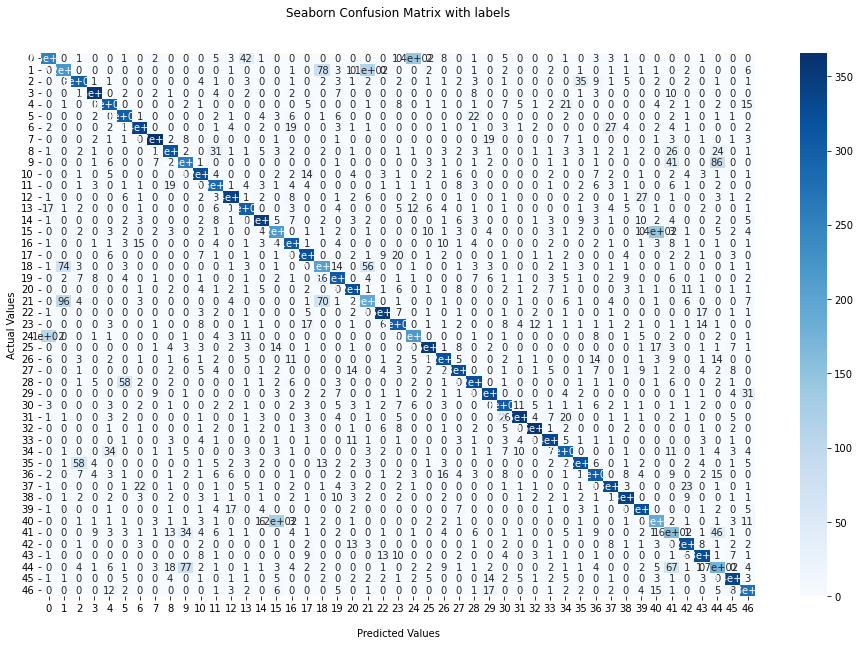

In [10]:
showConfusionMatrix(grid, X_test, y_test)

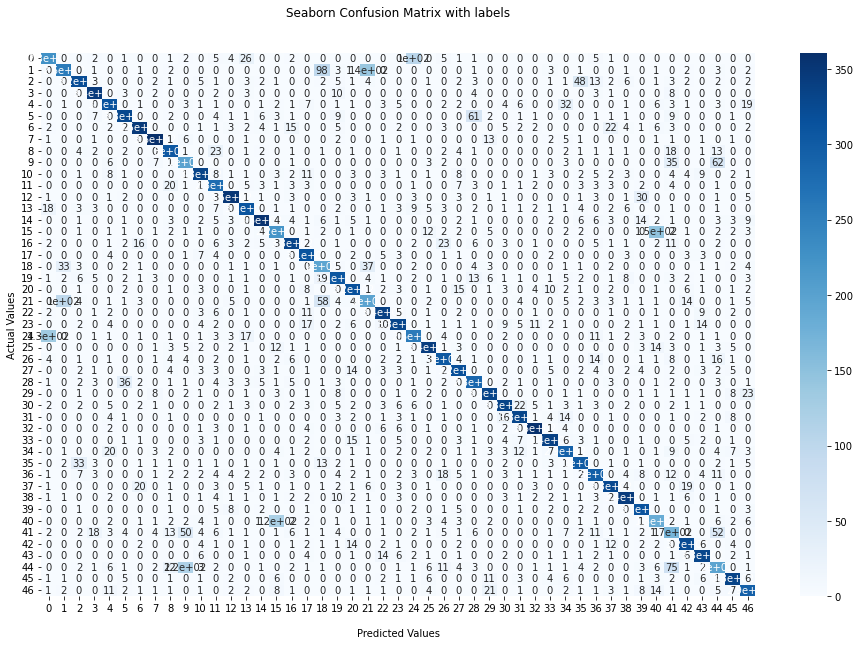

In [11]:
showConfusionMatrix(rando, X_test, y_test)